# 4.1. 같은 방정식, 다른 의미

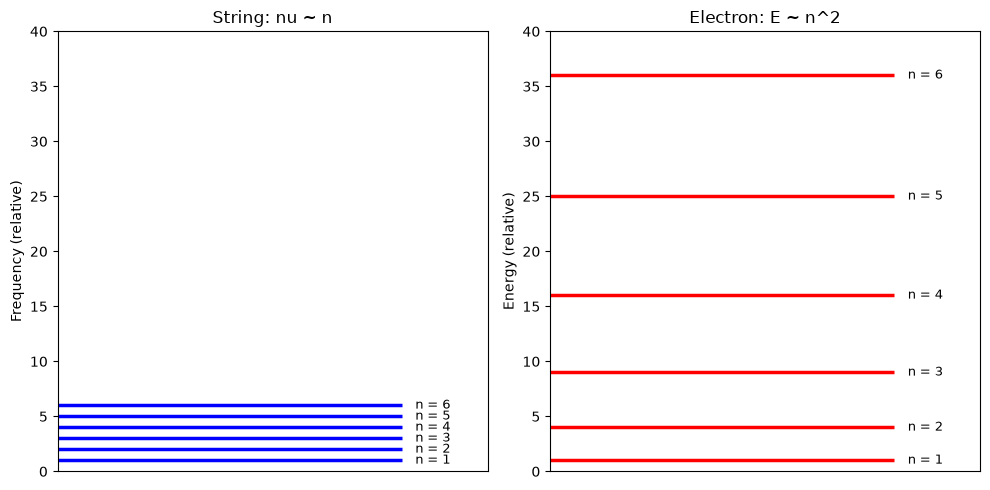

In [1]:
import numpy as np
import matplotlib.pyplot as plt

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 5))

for n in range(1, 7):
    a1.hlines(n, 0, 1, lw=2.5, color="blue")
    a2.hlines(n**2, 0, 1, lw=2.5, color="red")
    a1.text(1.04, n, f"n = {n}", va="center", fontsize=9)
    a2.text(1.04, n**2, f"n = {n}", va="center", fontsize=9)

for ax, ylab, title in [
    (a1, "Frequency", "String: nu ~ n"),
    (a2, "Energy", "Electron: E ~ n^2"),
]:
    ax.set_ylim(0, 40)
    ax.set_xlim(0, 1.25)
    ax.set_xticks([])
    ax.set_ylabel(f"{ylab} (relative)")
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [2]:
from scipy.constants import h, m_e, e


def energy_level(n, L_nm):
    L = L_nm * 1e-9
    return n**2 * h**2 / (8 * m_e * L**2) / e


for L_nm in [1, 2]:
    levels = [energy_level(n, L_nm) for n in range(1, 4)]
    print(
        f"L = {L_nm} nm: "
        + ", ".join(f"E_{n} = {E:6.4f} eV" for n, E in enumerate(levels, 1))
    )

L = 1 nm: E_1 = 0.3760 eV, E_2 = 1.5041 eV, E_3 = 3.3843 eV
L = 2 nm: E_1 = 0.0940 eV, E_2 = 0.3760 eV, E_3 = 0.8461 eV


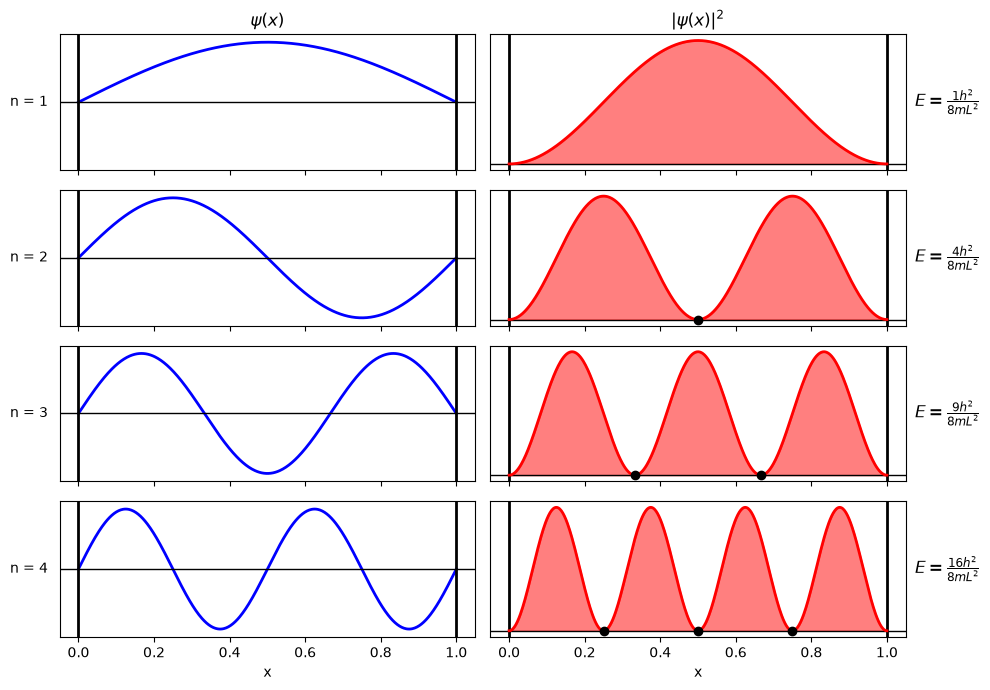

In [3]:
L = 1.0
x = np.linspace(0, L, 500)

fig, axes = plt.subplots(4, 2, figsize=(10, 7), sharex=True)

for i, n in enumerate([1, 2, 3, 4]):
    psi = np.sqrt(2 / L) * np.sin(n * np.pi * x / L)
    nodes = np.arange(1, n) * L / n

    axes[i, 0].plot(x, psi, color="blue", lw=2)
    axes[i, 0].axhline(0, color="black", lw=1)
    axes[i, 0].axvline(0, color="black", lw=2)
    axes[i, 0].axvline(L, color="black", lw=2)
    axes[i, 0].set_ylim(-1.6, 1.6)
    axes[i, 0].set_ylabel(f"n = {n}", rotation=0, labelpad=22, va="center")
    
    axes[i, 1].fill_between(x, psi**2, color="red", alpha=0.5)
    axes[i, 1].axhline(0, color="black", lw=1)
    axes[i, 1].axvline(0, color="black", lw=2)
    axes[i, 1].axvline(L, color="black", lw=2)
    axes[i, 1].plot(x, psi**2, color="red", lw=2)
    axes[i, 1].plot(nodes, np.zeros_like(nodes), "o", color="black", ms=6, zorder=5)
    axes[i, 1].yaxis.set_label_position("right")
    axes[i, 1].set_ylabel(f"$E = \\frac{{{n**2}h^2}}{{8mL^2}}$", labelpad=30, rotation=0, va="center", fontsize=12)

    for ax in axes[i]:
        ax.set_yticks([])

axes[0, 0].set_title("$\\psi(x)$")
axes[0, 1].set_title("$|\\psi(x)|^2$")
axes[-1, 0].set_xlabel("x")
axes[-1, 1].set_xlabel("x")

plt.tight_layout()
plt.show()